In [ ]:
# kaggle commands to laod the dataset

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d farzadnekouei/trash-type-image-dataset

Dataset URL: https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset
License(s): unknown
100% 40.9M/40.9M [00:00<00:00, 77.4MB/s]



In [4]:
!unzip -q trash-type-image-dataset.zip -d garbage_data

In [5]:
# loading dataset
import os
root_path = '/content/garbage_data'
os.listdir(root_path)

['TrashType_Image_Dataset']

In [6]:
# checking the category of garabges
sub_root = '/content/garbage_data/TrashType_Image_Dataset'
os.listdir(sub_root)

['cardboard', 'plastic', 'metal', 'glass', 'trash', 'paper']

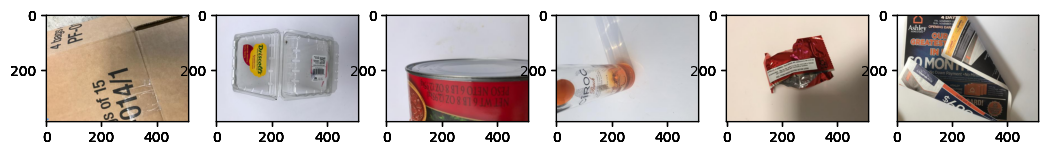

In [13]:
# showing the image of each category 7 images of each
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
fig = plt.figure(figsize=(15,15))

for category in os.listdir(sub_root):
  category_path = os.path.join(sub_root,category)
  ax = fig.add_subplot(1,7,os.listdir(sub_root).index(category)+1)
  img_path = random.choice(os.listdir(category_path))
  img = mpimg.imread(os.path.join(category_path,img_path))
  ax.imshow(img)

In [15]:
# checking how many images we have total
total_images = 0
for category in os.listdir(sub_root):
  category_path = os.path.join(sub_root,category)
  total_images += len(os.listdir(category_path))
total_images

2527

In [16]:
# total images in each category
for category in os.listdir(sub_root):
  category_path = os.path.join(sub_root,category)
  print(f'{category} : {len(os.listdir(category_path))}')

cardboard : 403
plastic : 482
metal : 410
glass : 501
trash : 137
paper : 594


In [62]:
# loading and train test split fro trainging and validation

import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    sub_root,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    sub_root,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

# Function to duplicate the image tensor for the dual-input model
def format_example(image, label):
  return ({'resnet_input': image, 'vgg_input': image}, label)

train_ds = train_ds.map(format_example).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(format_example).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [43]:
# without transfer learning
from tensorflow import keras
from tensorflow.keras import layers , models

number_classes = 6
model = models.Sequential([
    layers.Rescaling(1./255,input_shape=(224,224,3)),
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(number_classes)
    ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [45]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,457,670 (24.63 MB)

 Trainable params: 6,457,222 (24.63 MB)

 Non-trainable params: 448 (1.75 KB)

In [46]:
# model fitting
model.fit(train_ds, epochs=10, batch_size=64,validation_data=val_ds)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.3071 - loss: 1.9418 - val_accuracy: 0.2455 - val_loss: 5.0418
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.4011 - loss: 1.6027 - val_accuracy: 0.3069 - val_loss: 2.7560
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.4402 - loss: 1.4951 - val_accuracy: 0.3703 - val_loss: 2.0362
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4679 - loss: 1.4321 - val_accuracy: 0.1802 - val_loss: 3.0532
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.4960 - loss: 1.3085 - val_accuracy: 0.4535 - val_loss: 1.4911
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.5366 - loss: 1.2558 - val_accuracy: 0.2653 - val_loss: 2.5042
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5455 - loss: 1.2104 - val_accuracy: 0.1980 - val_loss: 2.6158
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5732 - loss: 1.1496 - val_accuracy: 0.1960 -

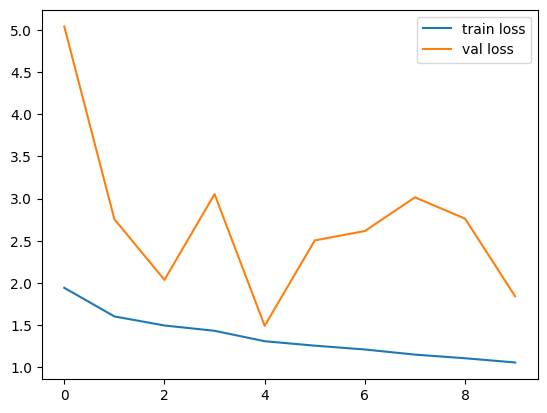

In [47]:
plt.plot(model.history.history['loss'], label='train loss')
plt.plot(model.history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [ ]:
# mannual trainging is not even crossing 50 percentage

In [48]:
# lets try training learning
# resnet + vggnet ( combined weightage )

In [50]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

In [78]:
# transfer learning model building

# Define explicit Input layers for each branch
resnet_input = tf.keras.Input(shape=(224, 224, 3), name='resnet_input')
vgg_input = tf.keras.Input(shape=(224, 224, 3), name='vgg_input')

# Apply preprocessing using Lambda layers to the Input tensors
resnet_prepped_output = layers.Lambda(resnet_preprocess, name='resnet_prepped')(resnet_input)
vgg_prepped_output = layers.Lambda(vgg_preprocess, name='vgg_prepped')(vgg_input)

base_resnet = ResNet50(weights='imagenet', include_top=False, input_tensor=resnet_prepped_output)
base_vgg = VGG16(weights='imagenet', include_top=False, input_tensor=vgg_prepped_output)

base_resnet.trainable = False
base_vgg.trainable = False

resnet_features = base_resnet.output
vgg_features = base_vgg.output

resnet_features = GlobalAveragePooling2D()(resnet_features)
vgg_features = GlobalAveragePooling2D()(vgg_features)

combined_features = Concatenate()([resnet_features, vgg_features])

combined_features = Dense(128, activation='relu')(combined_features)
combined_features = layers.BatchNormalization()(combined_features)
combined_features = Dropout(0.5)(combined_features)
output = Dense(number_classes, activation='softmax')(combined_features)

model = Model(inputs=[resnet_input, vgg_input], outputs=output)

In [54]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ resnet_input        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_prepped      │ (None, 224, 224,  │          0 │ resnet_input[0][… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ resnet_prepped[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c

 Total params: 38,630,982 (147.37 MB)

 Trainable params: 328,582 (1.25 MB)

 Non-trainable params: 38,302,400 (146.11 MB)

In [79]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [80]:
model.fit(train_ds, epochs=5, validation_data=val_ds)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 560ms/step - accuracy: 0.7136 - loss: 0.8547 - val_accuracy: 0.8416 - val_loss: 0.5635
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 378ms/step - accuracy: 0.8714 - loss: 0.3558 - val_accuracy: 0.8772 - val_loss: 0.3852
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 355ms/step - accuracy: 0.9130 - loss: 0.2558 - val_accuracy: 0.8970 - val_loss: 0.2957
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 359ms/step - accuracy: 0.9402 - loss: 0.1837 - val_accuracy: 0.9129 - val_loss: 0.2765
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.9674 - loss: 0.1248 - val_accuracy: 0.9208 - val_loss: 0.2476


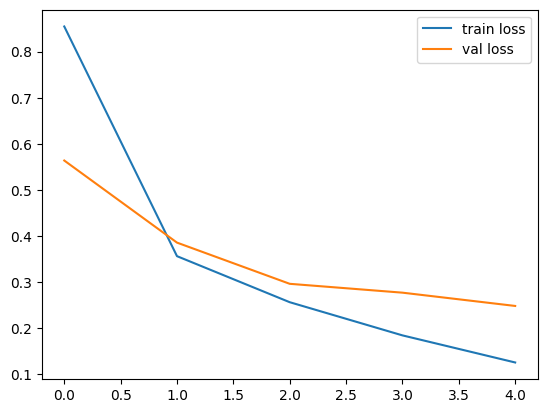

In [81]:
plt.plot(model.history.history['loss'], label='train loss')
plt.plot(model.history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [83]:
import plotly.express as px
import pandas as pd

history_df = pd.DataFrame(model.history.history)
history_df['epoch'] = history_df.index + 1

df_melted = history_df.melt(id_vars=['epoch'], var_name='metric', value_name='value')

loss_df = df_melted[df_melted['metric'].isin(['loss', 'val_loss'])]
fig_loss = px.line(loss_df, x='epoch', y='value', color='metric', title='Training and Validation Loss')
fig_loss.show()

accuracy_df = df_melted[df_melted['metric'].isin(['accuracy', 'val_accuracy'])]
fig_accuracy = px.line(accuracy_df, x='epoch', y='value', color='metric', title='Training and Validation Accuracy')
fig_accuracy.show()

In [85]:
# saving model
model.save('garbage_classifier.keras')

In [92]:
# testing the model
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, GlobalAveragePooling2D, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras import layers # Needed for layers.BatchNormalization and layers.Lambda

# Define number_classes, which was used in the original model definition
number_classes = 6 # This was defined in cell CfogEXpnKU27

# Re-create the model architecture exactly as it was defined before
resnet_input = tf.keras.Input(shape=(224, 224, 3), name='resnet_input')
vgg_input = tf.keras.Input(shape=(224, 224, 3), name='vgg_input')

# Apply preprocessing using Lambda layers to the Input tensors
# Ensure these Lambda layers reference the correct preprocess functions
resnet_prepped_output = layers.Lambda(resnet_preprocess, name='resnet_prepped')(resnet_input)
vgg_prepped_output = layers.Lambda(vgg_preprocess, name='vgg_prepped')(vgg_input)

# Instantiate base models with the preprocessed inputs
base_resnet = ResNet50(weights='imagenet', include_top=False, input_tensor=resnet_prepped_output)
base_vgg = VGG16(weights='imagenet', include_top=False, input_tensor=vgg_prepped_output)

# Set base models to non-trainable (as they were during training)
base_resnet.trainable = False
base_vgg.trainable = False

# Extract features
resnet_features = base_resnet.output
vgg_features = base_vgg.output

resnet_features = GlobalAveragePooling2D()(resnet_features)
vgg_features = GlobalAveragePooling2D()(vgg_features)

# Concatenate and add dense layers
combined_features = Concatenate()([resnet_features, vgg_features])
combined_features = Dense(128, activation='relu')(combined_features)
combined_features = layers.BatchNormalization()(combined_features) # Use tf.keras.layers or layers
combined_features = Dropout(0.5)(combined_features)
output = Dense(number_classes, activation='softmax')(combined_features)

# Create the model with the re-defined architecture
model_loaded = Model(inputs=[resnet_input, vgg_input], outputs=output)

# Load the weights into the re-created model.
# Since the model was saved with model.save(), it contains weights, architecture, and optimizer state.
# We have recreated the architecture, so we can now load the weights from the saved file.
# Note: For '.keras' format, load_weights can directly load from the .keras file.
model_loaded.load_weights('garbage_classifier.keras')

# Prepare the image for prediction
img_path = '/content/cardboard.png'
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create a batch for single image prediction

# Make prediction
# The model expects two inputs, so we provide the preprocessed image to both
predictions = model_loaded.predict({'resnet_input': img_array, 'vgg_input': img_array})
print(np.argmax(predictions))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
0


In [91]:
print(np.argmax(predictions))

5


In [ ]:
# 0	Cardboard
# 1	Glass
# 2	Metal
# 3	Paper
# 4	Plastic
# 5	Trash